In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import copy
import survey_time
import spectroscopic_efficiency

In [2]:
path = '../target_selection/photom_redshift_distribution/'

In [3]:
#bright time: BG_bright
#grey time: BG_Faint, LRG, ELG
config_survey_bright = {'survey_type': 'Bright',
                 'N_fibres': 30000,
                 'S_survey': 18000,
                 'exposure_time': 180, 
                 'observation_fraction': 0.8 * 0.5 * 0.2,
                 'tracer_N_zm_file' : [path+f'LS_BG_BRIGHT_WST.npz'],
                 'tracers' : ['BG_bright'],
                 'color' : ['orange']}
config_survey_grey = {'survey_type': 'Grey',
                 'N_fibres': 30000,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.35,
                 'tracer_N_zm_file' : [path+f'LS_BG_FAINT_WST.npz', path+f'LS_LRG_WST.npz', path+f'LS_ELG_WST.npz'],
                 'tracers' : ['BG_faint', 'LRG', 'ELG'],
                 'color' : ['orange', 'brown','peru']}

config_survey_dark = {'survey_type': 'Dark',
                 'N_fibres': 30000,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [path+f'COSMOS_QSO_WST_QSO_no_H.npz', path+f'COSMOS_LBG_udropout_highz.npz', path+f'COSMOS_LBG_gdropout.npz', path+f'COSMOS_LBG_rdropout.npz'],
                 'tracers' : ['QSO', 'LBGu', 'LBGg', 'LBGr'],
                    'color' : ['k', 'm','g','r']}

In [4]:
def Survey_time(config_survey):

    S_survey = config_survey['S_survey']
    N_fibres = config_survey['N_fibres']
    config_survey_update = copy.deepcopy(config_survey)
    for i, tracer in enumerate(config_survey['tracers']):
        N_zm = np.load(config_survey['tracer_N_zm_file'][i])
        mag_centers = N_zm['mag_center']
        z_centers = N_zm['z_center']
        n_target_count = N_zm['object_count'] / N_zm['surface_deg2']
        Efficiency = np.zeros([len(z_centers), len(mag_centers)])
        n_pass = np.zeros([len(z_centers), len(mag_centers)])
        for i, z in enumerate(z_centers):
            Efficiency[i,:] = spectroscopic_efficiency.E_wst(z, mag_centers, tracer = tracer)
            n_pass[i,:] = spectroscopic_efficiency.n_pass_wst(z, mag_centers, tracer = tracer)

        n_pointings = []
        n_target = []
        n_spec = []
        n_specz_redshift = []
        n_target_redshift = []
        for m in mag_centers:
            n_target.append(np.sum(np.sum(n_target_count[:, mag_centers <= m], axis=1), axis=0))
            n_spec.append(np.sum(np.sum((n_target_count * Efficiency)[:, mag_centers <= m], axis=1), axis=0))
            n_pointings.append(np.sum(np.sum((n_target_count * n_pass)[:, mag_centers <= m], axis=1), axis=0))
            n_specz_redshift.append(np.sum((n_target_count * Efficiency)[:, mag_centers <= m], axis=1))
            n_target_redshift.append(np.sum((n_target_count)[:, mag_centers <= m], axis=1))
        config_survey_update[tracer + '_' + 'target_density'] = np.array(n_target)
        config_survey_update[tracer + '_' + 'spec_density'] = np.array(n_spec)
        config_survey_update[tracer + '_' + 'spec_redshift_density'] = np.array(n_specz_redshift)
        config_survey_update[tracer + '_' + 'target_redshift_density'] = np.array(n_target_redshift)
        config_survey_update[tracer + '_' + 'target_pointings'] = np.array(n_pointings)
        config_survey_update[tracer + '_' + 'fibre_time'] = np.array(n_pointings) * config_survey['exposure_time']  * (S_survey / N_fibres) / (365.25 * 24 * 3600)
        config_survey_update[tracer + '_' + 'calendar_time'] = config_survey_update[tracer + '_' + 'fibre_time']/config_survey['observation_fraction']
        config_survey_update[tracer + '_' + 'mag_centers'] = np.array(mag_centers)
        config_survey_update[tracer + '_' + 'redshift_centers'] = np.array(z_centers)
    return config_survey_update

config_bright_update = Survey_time(config_survey_bright) 
config_grey_update = Survey_time(config_survey_grey)     
config_dark_update = Survey_time(config_survey_dark)   

2905.251641137855
4250.929978118162
2508.807439824945
21418.75027367868
2974.882526808366
5180.838323353293
4831.137724550898
994.6107784431138


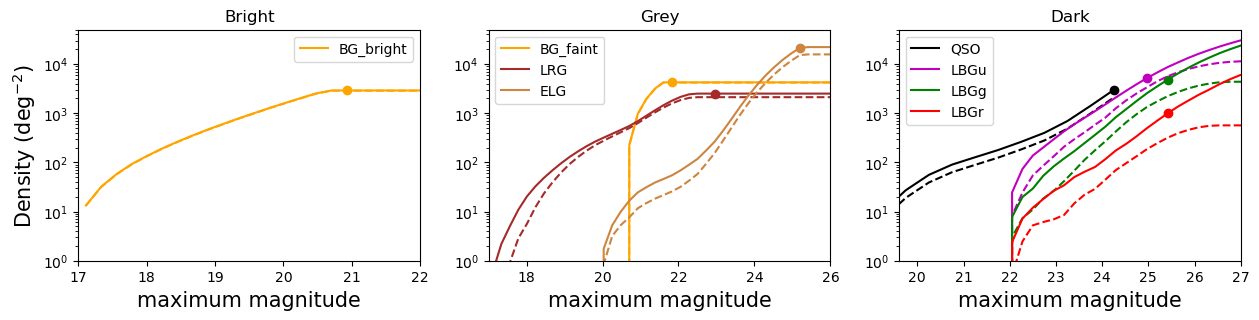

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 3))
mag_max = [[20.9], [21.9, 22.84, 25.3], [24.5, 25, 25.5, 25.5]]
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.subplot(131+i)
    plt.title(config['survey_type'])
    for j, tracer in enumerate(config['tracers']):
        plt.plot( config[tracer + '_' + 'mag_centers'], config[tracer + '_' + 'target_density'], f'-', color = config['color'][j], label = tracer)
        index = np.argmin(abs(config[tracer + '_' + 'mag_centers'] - mag_max[i][j]))
        plt.scatter(config[tracer + '_' + 'mag_centers'][index], config[tracer + '_' + 'target_density'][index], color = config['color'][j],)
        print(config[tracer + '_' + 'target_density'][index])
        plt.plot( config[tracer + '_' + 'mag_centers'], config[tracer + '_' + 'spec_density'], f'--', color = config['color'][j])

    #plt.ylabel(r'Density (deg$^{-2}$)', fontsize=15)
    if i==0: 
        plt.ylabel(r'Density (deg$^{-2}$)', fontsize=15)
        plt.xlim(17, 22)
    plt.ylim(1, 5e4)
    if i==1:
        plt.xlim(17, 26)
        plt.ylim(1, 5e4)

    if i==2:
        plt.xlim(19.6, 27)
        plt.ylim(1, 5e4)

    plt.legend()
    plt.xlabel('maximum magnitude', fontsize=15)
        
        
    plt.yscale('log')

plt.savefig(f'../figures/total_density.png', dpi = 300, bbox_inches='tight' )

/tmp/ipykernel_408864/980643374.py:8: RuntimeWarning: invalid value encountered in divide
  config[tracer + '_' + 'spec_density']/config[tracer + '_' + 'target_density'], f'', color = config['color'][j], label = tracer)


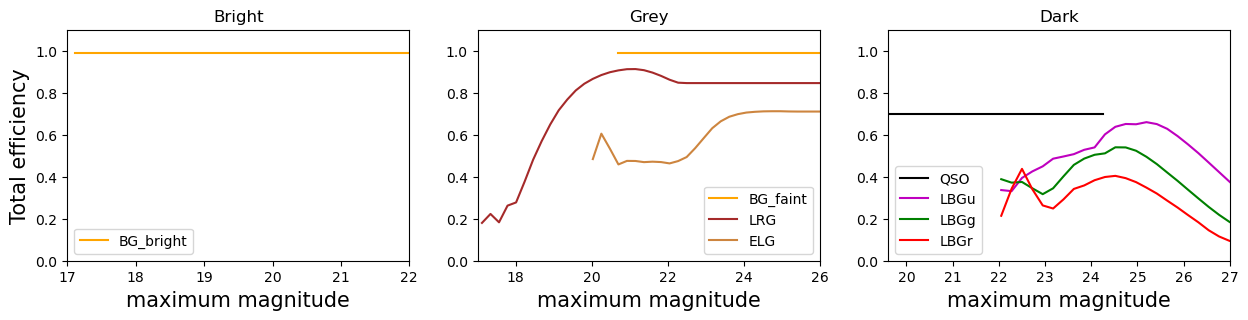

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 3))
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.subplot(131+i)
    plt.title(config['survey_type'])
    for j, tracer in enumerate(config['tracers']):
        plt.plot( config[tracer + '_' + 'mag_centers'], 
                 config[tracer + '_' + 'spec_density']/config[tracer + '_' + 'target_density'], f'', color = config['color'][j], label = tracer)


    if i==0: 
        plt.ylabel('Total efficiency', fontsize=15)
        plt.xlim(17, 22)
    plt.ylim(0,1.1)
    if i==1:
        plt.xlim(17, 26)


    if i==2:
        plt.xlim(19.6, 27)


    plt.legend()
    plt.xlabel('maximum magnitude', fontsize=15)
plt.savefig(f'../figures/total_efficiency.png', dpi = 300, bbox_inches='tight' )
        

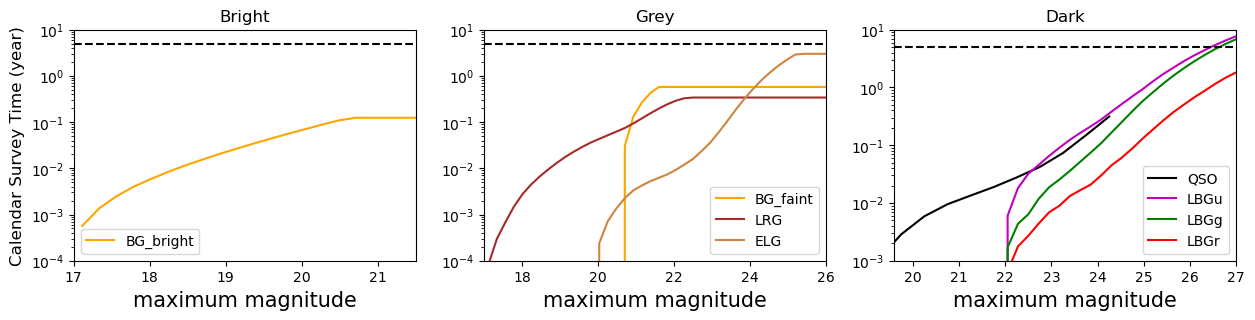

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 3))
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.subplot(131+i)
    plt.title(config['survey_type'])
    for j, tracer in enumerate(config['tracers']):
        plt.plot( config[tracer + '_' + 'mag_centers'], config[tracer + '_' + 'calendar_time'], f'-', color = config['color'][j], label = tracer)
    plt.axhline(5, color='k', ls='--')


    if i==0: 
        plt.ylabel('Calendar Survey Time (year)', fontsize=12)
        plt.xlim(17, 21.5)
        plt.ylim(0.0001, 10)
    
    if i==1:
        plt.xlim(17, 26)
        plt.ylim(0.0001, 10)
    #    plt.ylim(1, 5e4)

    if i==2:
        plt.ylim(0.001, 10)
        plt.xlim(19.6, 27)
    #    plt.ylim(1, 5e4)

    plt.legend()
    plt.xlabel('maximum magnitude', fontsize=15)
        
        
    plt.yscale('log')
#plt.savefig(f'../figures/total_survey_time.png', dpi = 300, bbox_inches='tight' )

0.12428352332040789
3.826810253308479
2.6811647696382206


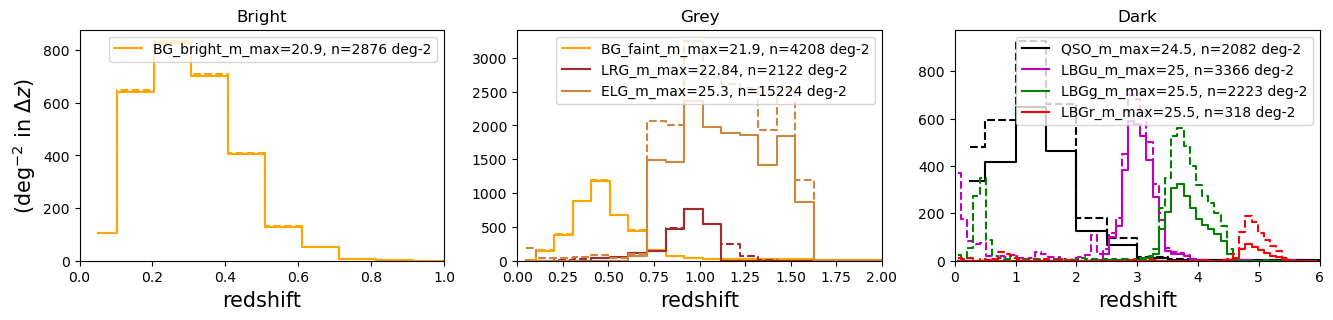

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 3))
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.subplot(131+i)
    plt.title(config['survey_type'])
    time = 0
    for j, tracer in enumerate(config['tracers']):
        index = np.argmin(abs(config[tracer + '_' + 'mag_centers'] - mag_max[i][j]))
        time += config[tracer + '_' + 'calendar_time'][index]
        n = config[tracer + '_' + 'spec_density'][index]

        z, x = config[tracer + '_' + 'redshift_centers'], config[tracer + '_' + 'spec_redshift_density'][index]
        x = x
        plt.step(z ,x, 
                 f'-',  color = config['color'][j], where='mid', label = tracer + f'_m_max={mag_max[i][j]}, n={n:.0f} deg-2')

        z, x = config[tracer + '_' + 'redshift_centers'], config[tracer + '_' + 'target_redshift_density'][index]
        x = x
        plt.step(z ,x, 
                 f'--',  color = config['color'][j], where='mid',)

        x = x
       # plt.step(z ,x, 
       #          f'--',  color = config['color'][j], where='mid')
    print(time)
    if i==0:
        plt.xlim(0,1)
        plt.ylabel(r'(deg$^{-2}$ in $\Delta z$)', fontsize=15)


    plt.legend()
    if i==1: plt.xlim(0, 2)
    if i==2: plt.xlim(0, 6)
    #plt.ylim(0, 3)
    plt.ylim(0)
    
    plt.xlabel('redshift', fontsize=15)

plt.savefig(f'../figures/total_redshift_density.png', dpi = 300, bbox_inches='tight' )

In [9]:
p = np.arange(1, 5)
T_of_p = p * 1000 * (18000/3)/(365.25 * 24 * 3600)
frac_obs = 0.8 * 0.5 * 0.45

2905.251641137855
28178.487691621787
25383.33760030054


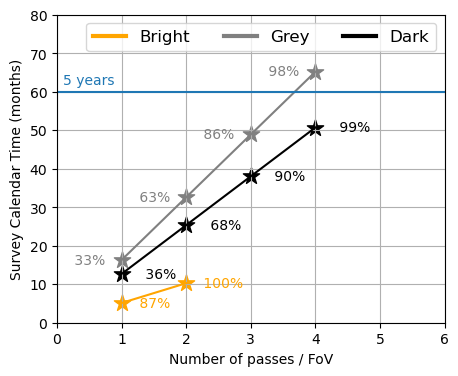

In [10]:
import matplotlib.pyplot as plt
color = ['orange', 'gray', 'k']
shift = [0.2, -0.8, 0.3]
plt.figure(figsize=(5,4))
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
   # if i > 0: break
    config_time =[]
    time = 0
    n_pointings = 0
    for j, tracer in enumerate(config['tracers']):
        index = np.argmin(abs(config[tracer + '_' + 'mag_centers'] - mag_max[i][j]))
        time += config[tracer + '_' + 'calendar_time'][index]
        n_pointings += config[tracer + '_' + 'target_pointings'][index]

    nf = 30000/3
    pmax = int(n_pointings / nf)+1

    print(n_pointings)

    n, cumulative, Xremaining, nleft = survey_time.passes_needed(n_pointings, 30000/3, n_pointings, max_passes=2000, coll=True, poiss=True)
    for j in range(1,len(nleft)):

        t = (j) * config['exposure_time'] * (config['S_survey'] / 3)
        t = t/(365.25 * 24 * 3600)

        completeness = 1 - nleft[j]/n_pointings
        if completeness > 0.999: continue

#plt.plot(p, T_of_p * 12/frac_obs)
        plt.scatter(j, t*12/config['observation_fraction'], color = color[i], marker='*', s=150)
        plt.text(j+shift[i], -1+t*12/config['observation_fraction'], f' {100*completeness:.0f}%', color = color[i],)

        config_time.append(t*12/config['observation_fraction'])
    plt.plot(np.arange(len(config_time))+1, config_time,color=color[i])

plt.xlabel('Number of passes / FoV')
plt.ylabel('Survey Calendar Time (months)')
#plt.axhline(12, color = 'm', lw=1)
#plt.axhline(24, color = 'm', lw=1)
#plt.axhline(36, color = 'm', lw=1)
#plt.axhline(12*4, color = 'm', lw=1)
#plt.text('1', 13,'1 year' , color = 'm')
#plt.text('1', 25,'2 years' , color = 'm')
#plt.text('1', 37,'3 years' , color = 'm')
#plt.text('1', 12*4+1,'4 years' , color = 'm')
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.plot([], [], color = color[i], label = config['survey_type'], lw=3)
plt.ylim(0, 80)
plt.xlim(-0, 6)
plt.grid()
plt.text(0.1, 62, '5 years', color='C0')
plt.axhline(5*12)
#plt.ylim(2, 40)
plt.legend(ncols=3, fontsize=12)
plt.savefig('../figures/survey_calendar_time.png', dpi = 300, bbox_inches='tight',)